In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from GB84_eqs import f as flux, rho_m
from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the data

In [2]:
#time to check
slice_str = "2024-07-16T00:00:00, 2024-07-16T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


In [3]:
#profile data
data_era = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\ERA5\profiles\*.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))
data_era = data_era.sel(latitude=51.96,longitude=4.9,method='nearest')
data_era = data_era.sortby('pressure_level', ascending=False)
data_era = data_era.sel(pressure_level=slice(1e5,200))


my_temp = data_era.t.values
p = data_era.pressure_level*100
q_v = data_era.q.values
Z = data_era.z.values/g     #z is geopotential in ERA5


In [4]:
#surface data
data_surf_era = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\ERA5\surface\*.nc')
data_surf_era = data_surf_era.sel(valid_time=slice(*slice_tuple))
data_surf_era = data_surf_era.sel(latitude=51.96,longitude=4.9,method='nearest')

my_temp_surface = data_surf_era.t2m.values
p_surface = data_surf_era.sp.values
T_d = data_surf_era.d2m.values
Z_surface = 2*np.ones(len(p_surface))       #2m

In [5]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

In [6]:
# calculating the surface specific humidity and inserting it to the profiles
def relative_humidity(t_air, t_dew):
    """
    t_air and t_dew in Celsius
    Returns RH in %
    """
    rh = 100 * (np.exp((17.67 * t_dew) / (t_dew + 243.5)) / 
                np.exp((17.67 * t_air) / (t_air + 243.5)))
    return rh

RH_surf = relative_humidity(my_temp_surface, T_d)

#### Parsivel rainfall data

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


#### Environmental profiles and inputs

In [8]:
#inserting the surface measurements at the profiles
T_air = np.concatenate([my_temp_surface.reshape(len(my_temp_surface), 1), my_temp], 1)
p_surf = p_surface #[Pa]
p_air = np.tile(p.values,(len(p_surf),1))
p_air = np.concatenate([p_surf.reshape(len(p_surf), 1), p_air], 1) #[Pa]
Z = np.concatenate([Z_surface.reshape(len(Z_surface), 1), Z], 1)

q_v_surf = specific_humidity_from_rh(my_temp_surface,RH_surf/100, p_surf)
q_v_air = np.concatenate([q_v_surf.reshape(len(q_v_surf), 1), q_v], 1) 

## Running the model

### Parcel Profiles

In [9]:
rows = T_air.shape[0]
cols = T_air.shape[1]

In [10]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


In [11]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.Temp_prof(T_air[i,0],p_air[i,0],T_d[i],p_air[i])

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.T_v(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [12]:
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

In [13]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [14]:
p_t_value = 30000
T_high = 220

#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],p_t_value,T_v_moist[i],T_v_env[i],T_high,temp_parcel[i])

### Updraft speed

In [15]:
import updraft_emmanuel

w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) < 0)
    #print(top_index,int(LFC_index[i,1]))
    w_parcel_max[i],CAPE = updraft_emmanuel.w_parcel(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)
w_parcel_max,CAPE

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


(array([ 0.        ,  0.        ,  5.10371709,  0.37052439,  1.00765616,
         0.        ,  0.75605959,  1.57042931, 14.12225536, 23.18011262,
        36.17124999, 38.50138399, 30.41163128,  1.89852353, 24.32665076,
        28.26739632, 27.92458264, 17.37732027,  1.78972092,  1.78473524,
        11.66566007,  0.94100029,  1.34618694,  0.94684096]),
 0.4482539055073394)

### State calculation and update

In [16]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) < 0)

    w_avg = w_parcel_max[i]/2
    rho = rho_m(T_s[i],my_temp[i,min(top_index,cols-1)],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = flux(T_d[i],p_new[i,0],p_t[i],my_temp[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])

0
1
2
3
2
4
2
5
6
7
2
8
2
9
2
10
2
11
2
12
2
13
2
14
2
15
2
16
2
17
2
18
2
19
2
20
2
21
2
22
2
23


#### Rainfall rates

In [ ]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]==0:
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_D_c()
        P[i] = nr.precipitation_rate(ar.autoconoversion_rate(X[i],Z_c[i],thresh), mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

0.3164337896438696 19.230014361229724
0.14496310580656435 17.743929352214206
-0.07917749640583227 15.810537501809975
-0.5022016350630765 12.18937598381613
-0.4411873166400857 12.709460384862462
-0.3661918830209099 13.349732687822769
-0.49749438125544154 12.22947423882823
0.2957415510338939 19.050355465557715
-0.24383969260606753 14.39672564622558
-0.26308137460061176 14.231871492052734
0.5921689426130785 21.63268449083146
0.6302327871818492 21.96563080851095
0.5480832241004083 21.247451747942204
0.7476172007718451 22.994358485730334
1.1788377926204558 26.79925652663937
2.674613319362005 40.328392387203685
0.23105122423768987 18.489263673779526
0.7662868159803427 23.158248400819385
0.4131412968989443 20.070862492060826
0.44495711858852327 20.34792416696847
0.25142685709578916 18.665897561240435
0.8291446530695945 23.710597198614913
0.33242042790394755 19.368878661157893
0.5597229161352553 21.349122167405298
1.0398001778075556 25.567976994405505
3.737483066831433 50.28011035822867
9.1819

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

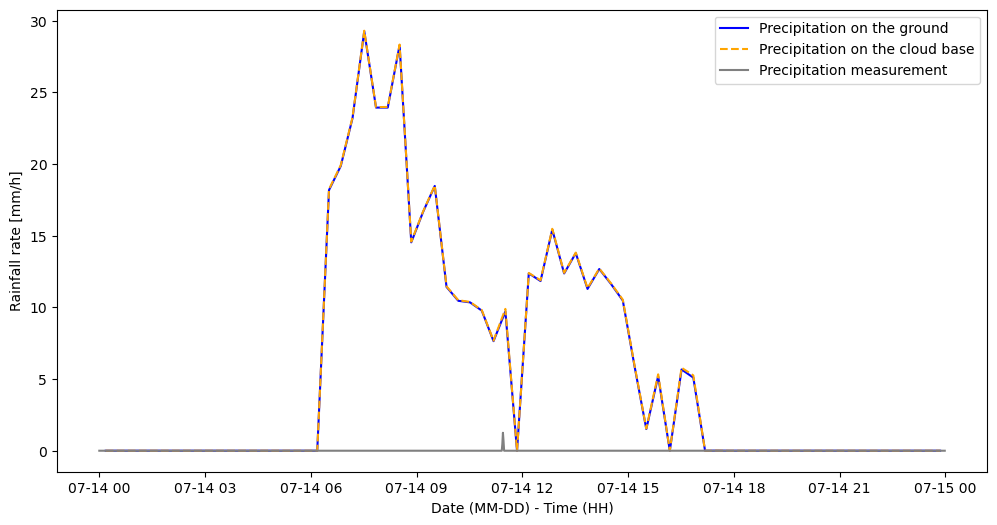

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

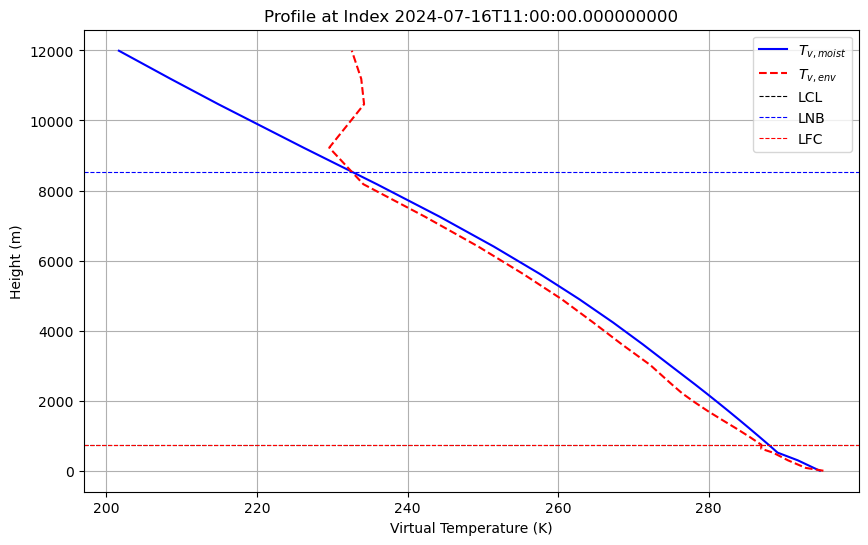

In [37]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

#### Cloud top and base

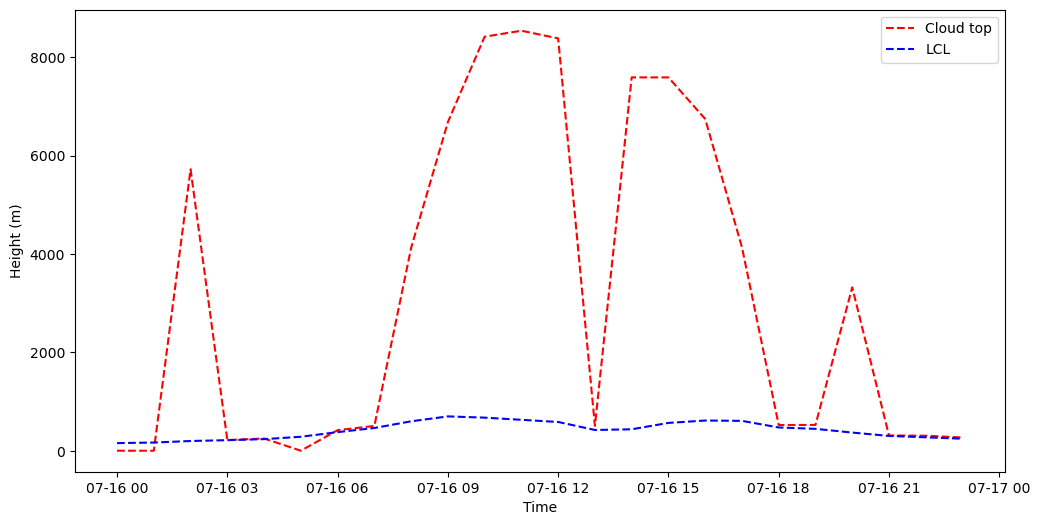

In [48]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

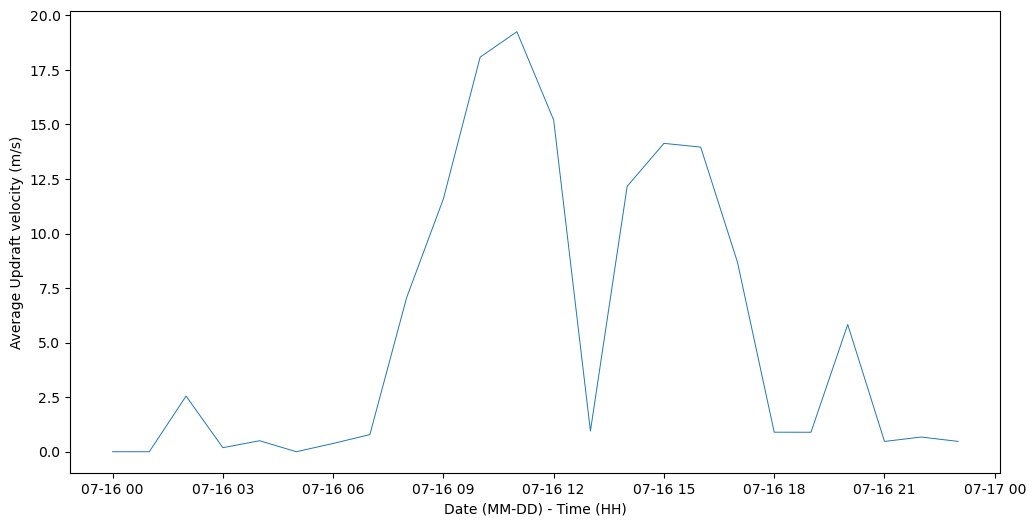

In [17]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

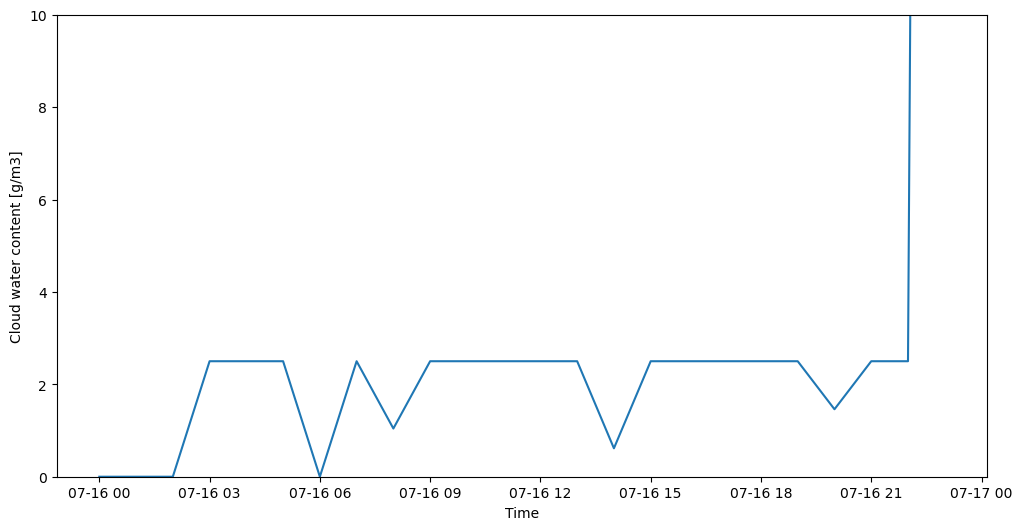

In [18]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

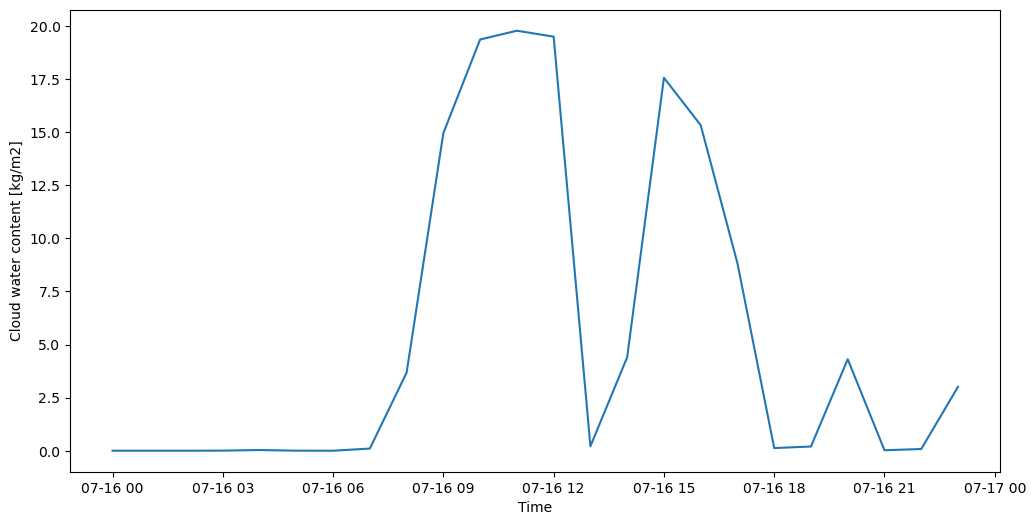

In [19]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

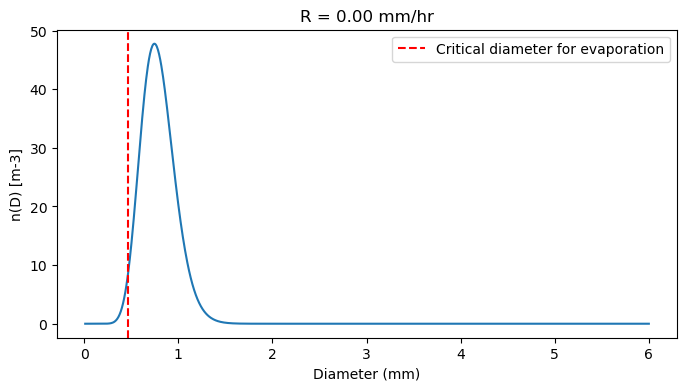

In [ ]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()